In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers torchvision scikit-learn -q

In [ ]:
import os
import torch
import pandas as pd

from PIL import Image

from torchvision import transforms
from transformers import SwinForImageClassification

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [ ]:
model = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=2,
    ignore_mismatched_sizes=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
model.load_state_dict(
    torch.load(
        "/content/swin_fruit_binary.pth" ,#Path to model
        map_location=device
    )
)

<All keys matched successfully>

In [ ]:
model.to(device)
model.eval()

SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (attention): SwinAttention(
                (q_proj): Linear(in_features=96, out_features=96, bias=True)
                (k_proj): Linear(in_features=96, out_features=96, bias=True)
                (v_proj): Linear(in_features=96, out_features=96, bias=True)
                (o_proj): Linear(in_features=96, out_features=96, bias=True)
                (relative_position_bias): SwinRelativePositionBias()
              )
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
         

In [ ]:
id2label = {
    0: "defective",
    1: "healthy"
}

In [ ]:
transform = transforms.Compose([
    transforms.Resize(256),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving moldapple.jpeg to moldapple.jpeg


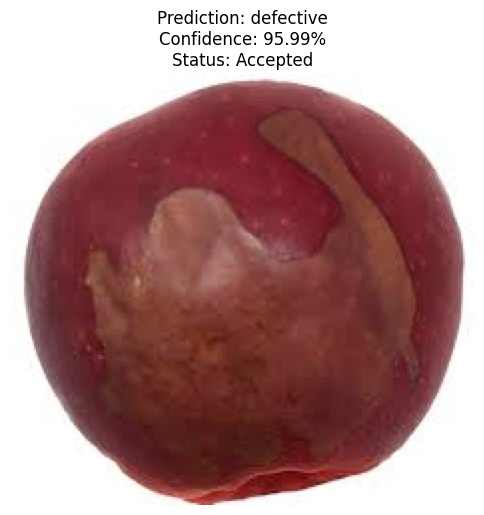

Prediction : defective
Confidence : 0.9599
Status     : Accepted


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Path to image
IMAGE_PATH = " "   # Change this

# Load image
image = Image.open(IMAGE_PATH).convert("RGB")

# Preprocess
input_tensor = transform(image).unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    outputs = model(pixel_values=input_tensor)

    probs = torch.softmax(outputs.logits, dim=1)

    confidence, pred = torch.max(probs, dim=1)

predicted_class = id2label[pred.item()]
confidence_score = confidence.item()

status = (
    "Needs Review"
    if confidence_score < 0.7
    else "Accepted"
)

# Display image with prediction
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence_score:.2%}\n"
    f"Status: {status}"
)

plt.show()

# Print result
print(f"Prediction : {predicted_class}")
print(f"Confidence : {confidence_score:.4f}")
print(f"Status     : {status}")

In [ ]:
import zipfile
FOLDER_PATH=" " #Change this
with zipfile.ZipFile(
    FOLDER_PATH,
    "r"
) as zip_ref:
    zip_ref.extractall("/content")

In [ ]:
import os

print(
    os.listdir("/content/evaluation")
)

['defective', 'healthy']


In [ ]:
healthy_dir = "/content/evaluation/healthy"
defective_dir = "/content/evaluation/defective"

In [ ]:
import os

print("Healthy:", len(os.listdir(healthy_dir)))
print("Defective:", len(os.listdir(defective_dir)))

Healthy: 30
Defective: 30


In [ ]:
results = []

In [ ]:
CONFIDENCE_THRESHOLD = 0.70

In [ ]:
for image_name in os.listdir(healthy_dir):

    image_path = os.path.join(
        healthy_dir,
        image_name
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    input_tensor = transform(
        image
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = model(input_tensor)

        probs = torch.softmax(
            outputs.logits,
            dim=1
        )

        confidence, pred = probs.max(dim=1)

    results.append({
        "image": image_name,
        "actual": "healthy",
        "prediction": id2label[pred.item()],
        "confidence": confidence.item(),
        "needs_review":
            confidence.item() < CONFIDENCE_THRESHOLD
    })

In [ ]:
import os
import shutil

os.makedirs(
    "/content/review_queue",
    exist_ok=True
)

review_log = []

In [ ]:
for image_name in os.listdir(defective_dir):

    image_path = os.path.join(
        defective_dir,
        image_name
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    input_tensor = transform(
        image
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = model(input_tensor)

        probs = torch.softmax(
            outputs.logits,
            dim=1
        )

        confidence, pred = probs.max(dim=1)

    results.append({
        "image": image_name,
        "actual": "defective",
        "prediction": id2label[pred.item()],
        "confidence": confidence.item(),
        "needs_review":
            confidence.item() < CONFIDENCE_THRESHOLD
    })

In [ ]:
import pandas as pd

df = pd.DataFrame(results)

df.head()

,image,actual,prediction,confidence,needs_review
0,liana-mikah-ziWMqRTdGXc-unsplash.jpg,healthy,healthy,0.795995,False
1,b6.jpeg,healthy,healthy,0.879555,False
2,carlos-alberto-gomez-iniguez-jNj2ldEc4N0-unspl...,healthy,healthy,0.797360,False
3,corina-rainer-hnqQESm6yAg-unsplash.jpg,healthy,healthy,0.846782,False
4,marek-studzinski-3D6yReT06p0-unsplash.jpg,healthy,healthy,0.929329,False


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(
    classification_report(
        df["actual"],
        df["prediction"]
    )
)

print(
    confusion_matrix(
        df["actual"],
        df["prediction"]
    )
)

              precision    recall  f1-score   support

   defective       0.93      0.87      0.90        30
     healthy       0.88      0.93      0.90        30

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60

[[26  4]
 [ 2 28]]


In [ ]:
print(
    df["needs_review"]
    .value_counts()
)

needs_review
False    52
True      8
Name: count, dtype: int64


In [ ]:
review_df = df[
    df["needs_review"] == True
]

print(
    f"{len(review_df)} images require review"
)

review_df

8 images require review


,image,actual,prediction,confidence,needs_review
12,b15.jpeg,healthy,healthy,0.608834,True
13,kelly-sikkema-E8AYWP4U6w0-unsplash.jpg,healthy,healthy,0.578553,True
20,anna-kaminova-BhZuCnDp7nU-unsplash.jpg,healthy,healthy,0.551569,True
36,b12.jpeg,defective,defective,0.533006,True
38,b4.jpeg,defective,defective,0.517199,True
41,b15.jpeg,defective,healthy,0.501035,True
42,giuseppe-cuzzocrea-E5kBdpQ7kQw-unsplash.jpg,defective,defective,0.686541,True
56,rasa-kasparaviciene-rsf-mbDfdY0-unsplash.jpg,defective,defective,0.511885,True


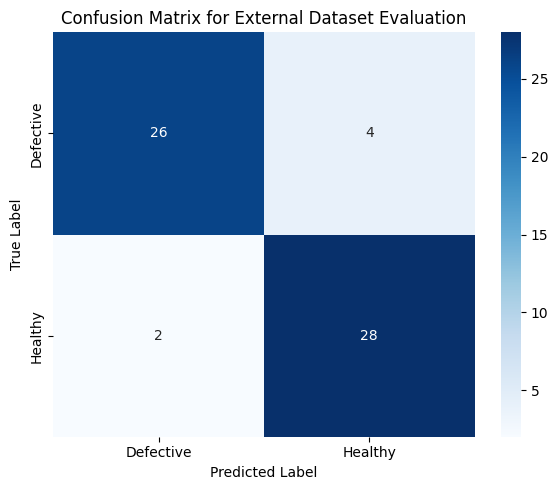

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = [[26, 4],
      [2, 28]]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Defective', 'Healthy'],
    yticklabels=['Defective', 'Healthy']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for External Dataset Evaluation')

plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
from PIL import Image
import os

feedback_labels = []
current_idx = 0

In [ ]:
def show_image():

    global current_idx

    if current_idx >= len(review_df):

        print("Review Complete")

        return

    row = review_df.iloc[current_idx]

    image_name = row["image"]
    actual_folder = row["actual"]

    image_path = os.path.join(
        "/content/evaluation",
        actual_folder,
        image_name
    )

    img = Image.open(image_path)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print(
        f"Image {current_idx+1}/{len(review_df)}"
    )

    print(
        f"Prediction: {row['prediction']}"
    )

    print(
        f"Confidence: {row['confidence']:.2f}"
    )

In [ ]:
healthy_btn = widgets.Button(
    description="Healthy"
)

defective_btn = widgets.Button(
    description="Defective"
)

output = widgets.Output()

In [ ]:
def mark_healthy(b):

    global current_idx

    row = review_df.iloc[current_idx]

    feedback_labels.append({
        "image": row["image"],
        "label": "healthy"
    })

    current_idx += 1

    output.clear_output()

    show_image()


def mark_defective(b):

    global current_idx

    row = review_df.iloc[current_idx]

    feedback_labels.append({
        "image": row["image"],
        "label": "defective"
    })

    current_idx += 1

    output.clear_output()

    show_image()

Output()

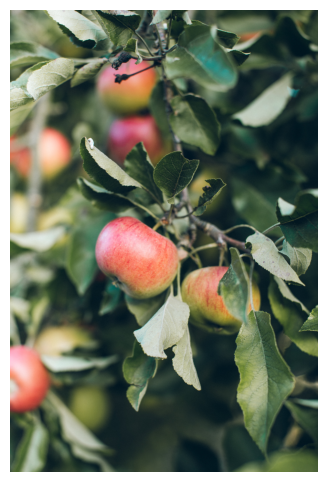

Image 1/9
Prediction: defective
Confidence: 0.56


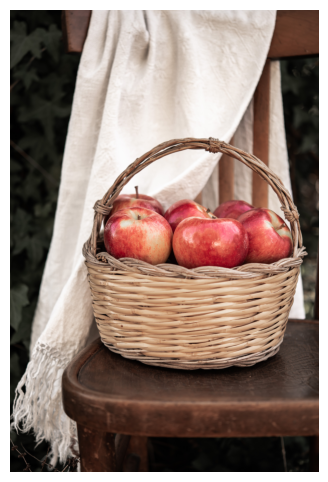

Image 2/9
Prediction: healthy
Confidence: 0.56


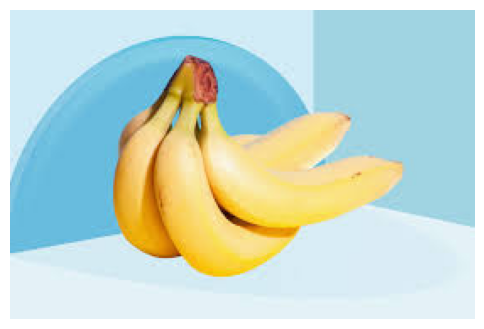

Image 3/9
Prediction: healthy
Confidence: 0.60


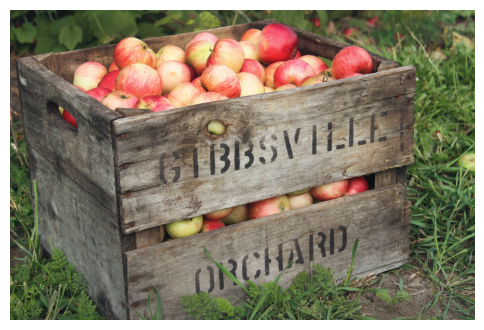

Image 4/9
Prediction: defective
Confidence: 0.52


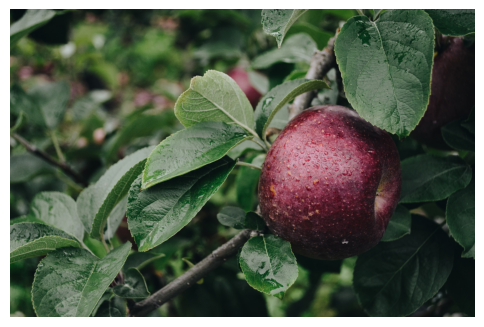

Image 5/9
Prediction: healthy
Confidence: 0.52


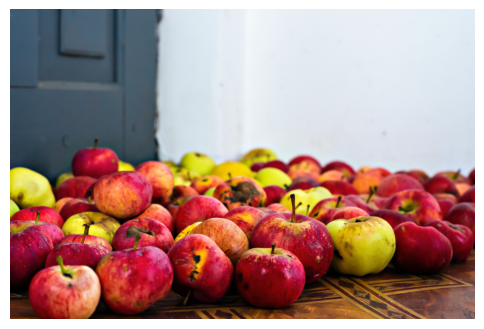

Image 6/9
Prediction: healthy
Confidence: 0.63


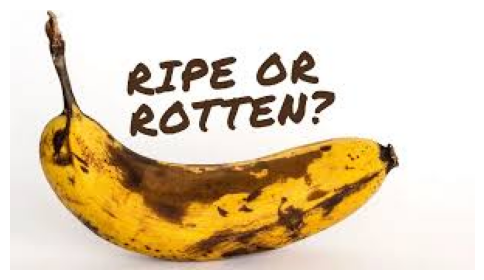

Image 7/9
Prediction: defective
Confidence: 0.61


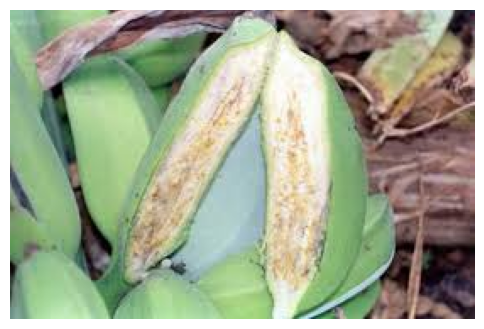

Image 8/9
Prediction: defective
Confidence: 0.61


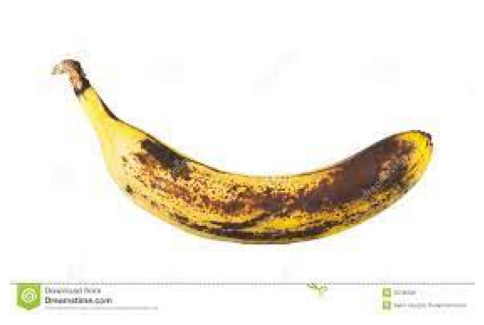

Image 9/9
Prediction: defective
Confidence: 0.56
Review Complete


In [ ]:
healthy_btn.on_click(
    mark_healthy
)

defective_btn.on_click(
    mark_defective
)

display(
    widgets.HBox([
        healthy_btn,
        defective_btn
    ])
)

display(output)

show_image()

In [ ]:
feedback_df = pd.DataFrame(
    feedback_labels
)

feedback_df

,image,label
0,anna-kaminova-BhZuCnDp7nU-unsplash.jpg,healthy
1,vera-de-4Bj27zMqNSE-unsplash.jpg,healthy
2,b15.jpeg,healthy
3,jen-theodore-Nd22Byt2ITA-unsplash.jpg,healthy
4,kelly-sikkema-E8AYWP4U6w0-unsplash.jpg,healthy
5,rasa-kasparaviciene-rsf-mbDfdY0-unsplash.jpg,defective
6,b15.jpeg,defective
7,b12.jpeg,defective
8,b4.jpeg,defective


In [ ]:
import os
import shutil

os.makedirs(
    "/content/feedback_dataset/healthy",
    exist_ok=True
)

os.makedirs(
    "/content/feedback_dataset/defective",
    exist_ok=True
)

for _, row in feedback_df.iterrows():

    image_name = row["image"]
    label = row["label"]

    for folder in [
        "healthy",
        "defective"
    ]:

        source_path = os.path.join(
            "/content/evaluation",
            folder,
            image_name
        )

        if os.path.exists(source_path):

            shutil.copy(
                source_path,
                f"/content/feedback_dataset/{label}"
            )

            break

print("Feedback dataset created")

Feedback dataset created


In [ ]:
import shutil

shutil.copytree(
    "/content/feedback_dataset",
    "/content/drive/MyDrive/feedback_dataset",
    dirs_exist_ok=True
)

print("Feedback dataset saved to Drive")

Feedback dataset saved to Drive


In [ ]:
print(
    "Healthy:",
    len(os.listdir(
        "/content/feedback_dataset/healthy"
    ))
)

print(
    "Defective:",
    len(os.listdir(
        "/content/feedback_dataset/defective"
    ))
)

Healthy: 6
Defective: 4
